In [11]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Загрузка данных...
 Обучающая выборка: (60000, 28, 28)
 Тестовая выборка: (10000, 28, 28)


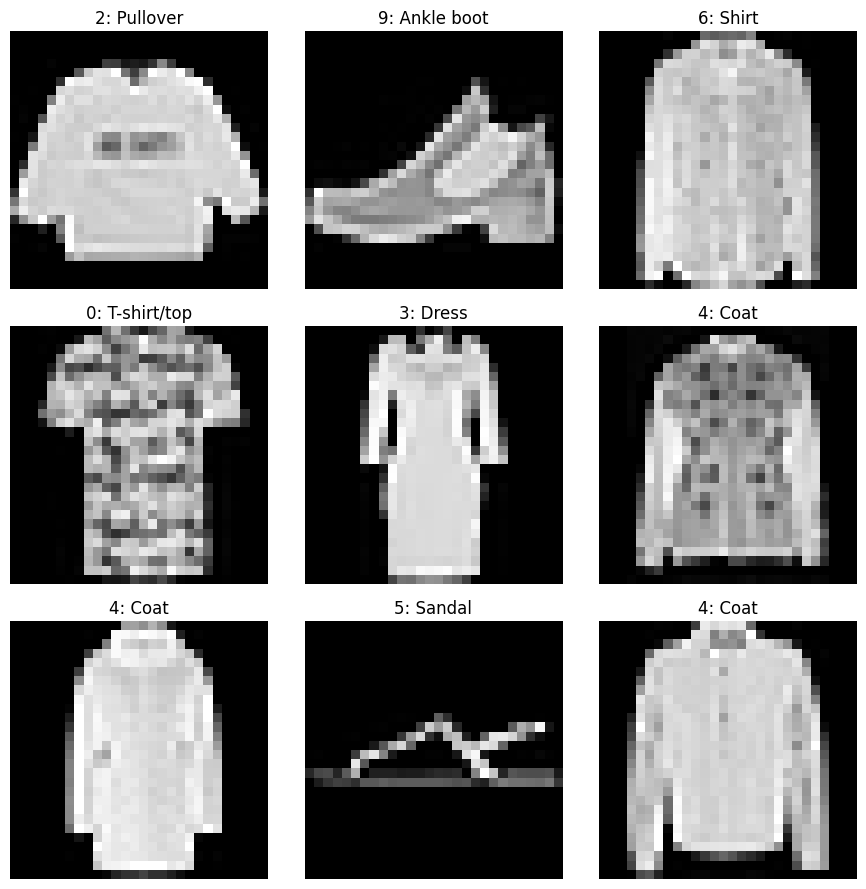

In [10]:
FOLDER_PATH = '/content/drive/MyDrive/fashion_mnist_data/'

print("Загрузка данных...")
train_df = pd.read_csv(FOLDER_PATH + 'fashion-mnist_train.csv')
test_df = pd.read_csv(FOLDER_PATH + 'fashion-mnist_test.csv')

y_train = train_df['label'].values
X_train = train_df.drop('label', axis=1).values.reshape(-1, 28, 28)

y_test = test_df['label'].values
X_test = test_df.drop('label', axis=1).values.reshape(-1, 28, 28)

print(f" Обучающая выборка: {X_train.shape}")
print(f" Тестовая выборка: {X_test.shape}")

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"{y_train[i]}: {classes[y_train[i]]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
print("Data separation")
X_temp, X_val, y_temp, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
X_train_final, X_test_baseline, y_train_final, y_test_baseline = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)
print(f"Train: {X_train_final.shape}, Val: {X_val.shape}, Test: {X_test_baseline.shape}")

Data separation
Train: (48006, 28, 28), Val: (6000, 28, 28), Test: (5994, 28, 28)


In [13]:
X_train_tensor = torch.tensor(X_train_final.reshape(-1, 784), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_final, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.reshape(-1, 784), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_baseline.reshape(-1, 784), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_baseline, dtype=torch.long)

In [14]:
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [15]:
class MLPBaseline(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=10):
        super(MLPBaseline, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = MLPBaseline()
print("\nModel created:")
print(model)


Model created:
MLPBaseline(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
num_epochs = 20
train_losses = []
val_losses = []
val_accuracies = []

print("\nНачинаем обучение\n")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")


Начинаем обучение

Epoch  1/20 | Train Loss: 0.5781 | Val Loss: 0.4467 | Val Acc: 84.28%
Epoch  2/20 | Train Loss: 0.4191 | Val Loss: 0.4297 | Val Acc: 84.68%
Epoch  3/20 | Train Loss: 0.3778 | Val Loss: 0.3940 | Val Acc: 85.70%
Epoch  4/20 | Train Loss: 0.3507 | Val Loss: 0.3728 | Val Acc: 86.83%
Epoch  5/20 | Train Loss: 0.3308 | Val Loss: 0.3504 | Val Acc: 87.43%
Epoch  6/20 | Train Loss: 0.3118 | Val Loss: 0.3453 | Val Acc: 87.17%
Epoch  7/20 | Train Loss: 0.2995 | Val Loss: 0.3305 | Val Acc: 88.00%
Epoch  8/20 | Train Loss: 0.2868 | Val Loss: 0.3278 | Val Acc: 88.03%
Epoch  9/20 | Train Loss: 0.2784 | Val Loss: 0.3223 | Val Acc: 88.02%
Epoch 10/20 | Train Loss: 0.2656 | Val Loss: 0.3247 | Val Acc: 88.18%
Epoch 11/20 | Train Loss: 0.2585 | Val Loss: 0.3292 | Val Acc: 88.30%
Epoch 12/20 | Train Loss: 0.2484 | Val Loss: 0.3617 | Val Acc: 87.70%
Epoch 13/20 | Train Loss: 0.2449 | Val Loss: 0.3187 | Val Acc: 88.52%
Epoch 14/20 | Train Loss: 0.2352 | Val Loss: 0.3308 | Val Acc: 88.55%


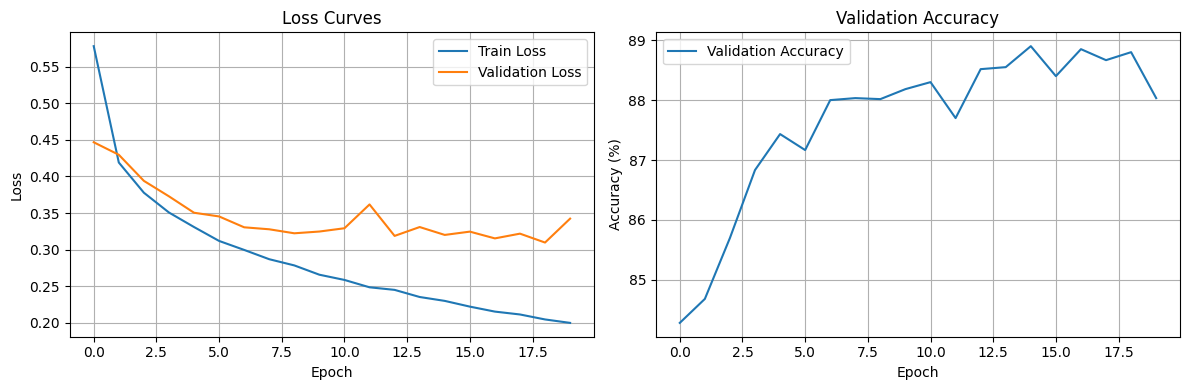

In [18]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Validation Accuracy')
plt.grid(True)

plt.tight_layout()
plt.savefig('/content/loss_curves.png')
plt.show()

In [19]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())

test_accuracy = 100 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\n Test accuracy (accuracy): {test_accuracy:.2f}%")



 Test accuracy (accuracy): 88.44%


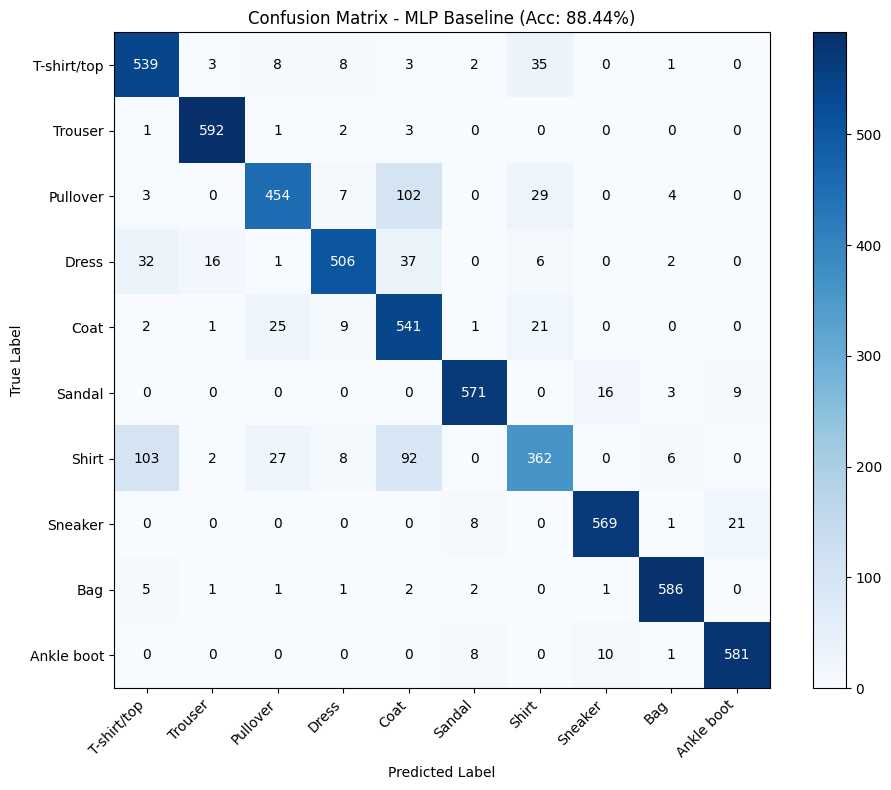

In [21]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f'Confusion Matrix - MLP Baseline (Acc: {test_accuracy:.2f}%)')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha='right')
plt.yticks(tick_marks, classes)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png')
plt.show()

In [22]:
f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
print(f"Macro F1-Score: {f1_macro:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")

Macro F1-Score: 0.8832
Weighted F1-Score: 0.8832


In [23]:
from collections import Counter
errors = []
for true, pred in zip(all_labels, all_preds):
    if true != pred:
        errors.append((true, pred))

error_pairs = Counter(errors)
print("\nTop 5 most common mistakes:")
for (true, pred), count in error_pairs.most_common(5):
    print(f"  {classes[true]} → {classes[pred]}: {count} раз")


Top 5 most common mistakes:
  Shirt → T-shirt/top: 103 раз
  Pullover → Coat: 102 раз
  Shirt → Coat: 92 раз
  Dress → Coat: 37 раз
  T-shirt/top → Shirt: 35 раз
